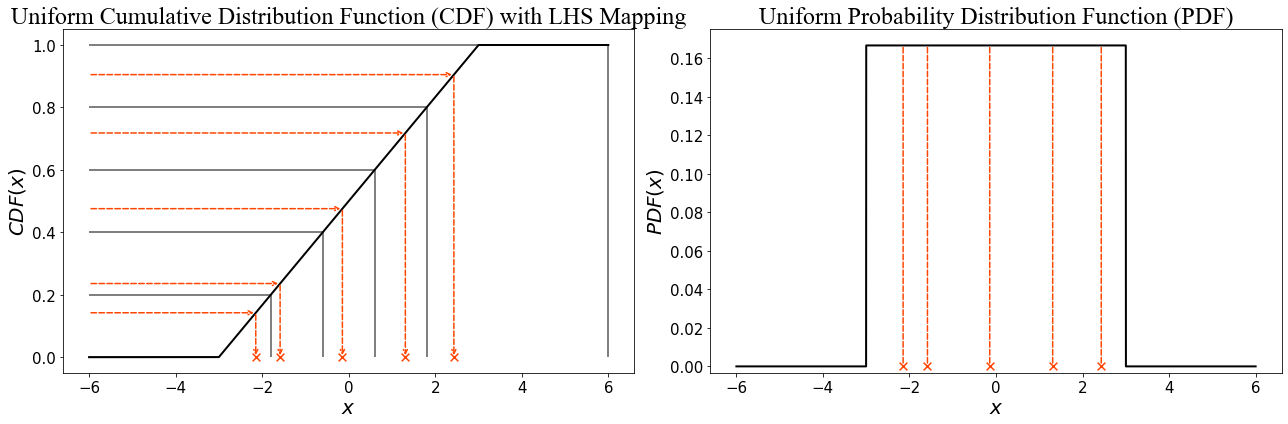

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

# ---------------------- USER TOGGLE / PARAMS ----------------------
dist_choice = 'uniform'            # 'normal' | 'skewed_left_normal' | 'uniform'
n_strata    = 5                   # number of LHS strata/samples
rng = np.random.default_rng()     # unseeded => new subset each run

# Normal params
mu_norm, sigma_norm = 0.0, 1.0

# Skew-normal params (Azzalini), alpha < 0 => left-skewed
alpha_skew = -6.0
loc_skew, scale_skew = 0.0, 1.0

# Uniform params
a_uni, b_uni = -3.0, 3.0

# ---------------------- Helpers ----------------------
def std_normal_pdf(z):
    return (1.0 / np.sqrt(2.0*np.pi)) * np.exp(-0.5*z*z)

def std_normal_cdf(z):
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def pdf_normal(x, mu, sigma):
    z = (x - mu) / sigma
    return std_normal_pdf(z) / sigma

def pdf_skew_normal(x, alpha, loc=0.0, scale=1.0):
    z = (x - loc) / scale
    return 2.0 * std_normal_pdf(z) * std_normal_cdf(alpha * z) / scale

def build_grid(choice):
    if choice == 'normal':
        low, high = mu_norm - 5*sigma_norm, mu_norm + 5*sigma_norm
    elif choice == 'skewed_left_normal':
        low, high = loc_skew - 8*scale_skew, loc_skew + 8*scale_skew
    elif choice == 'uniform':
        pad = 0.5*(b_uni - a_uni)
        low, high = a_uni - pad, b_uni + pad
    else:
        raise ValueError("Unknown choice")
    return np.linspace(low, high, 4000)

def make_pdf(choice, x):
    if choice == 'normal':
        pdf = pdf_normal(x, mu_norm, sigma_norm)
    elif choice == 'skewed_left_normal':
        pdf = pdf_skew_normal(x, alpha_skew, loc_skew, scale_skew)
    elif choice == 'uniform':
        pdf = np.zeros_like(x)
        mask = (x >= a_uni) & (x <= b_uni)
        pdf[mask] = 1.0 / (b_uni - a_uni)
    area = np.trapz(pdf, x)
    return pdf / area if area > 0 else pdf

def make_cdf_from_pdf(x, pdf):
    dx = np.diff(x)
    traps = 0.5*(pdf[:-1] + pdf[1:]) * dx
    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(traps)
    cdf = np.clip(cdf, 0.0, 1.0)
    cdf[-1] = 1.0
    return cdf

def inv_cdf_sample(x, cdf, u):
    cdf_mono = np.maximum.accumulate(cdf)
    return np.interp(u, cdf_mono, x)

# ---------------------- Build distribution & LHS ----------------------
x   = build_grid(dist_choice)
pdf = make_pdf(dist_choice, x)
cdf = make_cdf_from_pdf(x, pdf)

edges     = np.linspace(0.0, 1.0, n_strata+1)
u_samples = edges[:-1] + rng.random(n_strata) * (edges[1:] - edges[:-1])
x_samples = inv_cdf_sample(x, cdf, u_samples)

xmin = x[0]
pdf_at_samples = np.interp(x_samples, x, pdf)

# ---------------------- Plot (side-by-side subplots) ----------------------
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# ---- Left: PDF ----
ax = axs[1]
ax.plot(x, pdf, color='black', linewidth=2)
for xs, ys in zip(x_samples, pdf_at_samples):
    ax.annotate("", xy=(xs, 0.0), xytext=(xs, ys),
                arrowprops=dict(arrowstyle='-', linestyle='--',
                                color='orangered', linewidth=1.5))
ax.scatter(x_samples, np.zeros_like(x_samples),
           marker='x', color='orangered', s=60)
ax.set_title(f"{dist_choice.replace('_', ' ').title()} Probability Distribution Function (PDF)", fontsize=24, fontname="Times New Roman")
ax.set_xlabel("$x$", fontsize=20, fontname="Times New Roman")
ax.set_ylabel("$PDF(x)$", fontsize=20, fontname="Times New Roman")
ax.set_ylim(-0.02 * pdf.max(), 1.05 * pdf.max())
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=12)

# ---- Right: CDF ----
ax = axs[0]

# gray hlines/vlines that stop at the CDF
for e in edges:
    xe = inv_cdf_sample(x, cdf, e)
    ax.hlines(e, xmin, xe, colors='gray', linestyles='-', linewidth=2)
    ax.vlines(xe, 0.0, e, colors='gray', linestyles='-', linewidth=2)
ax.plot(x, cdf, color='black', linewidth=2)

# dashed orangered mapping arrows + x markers on input domain (y=0)
for u, xs in zip(u_samples, x_samples):
    ax.annotate("", xy=(xs, u), xytext=(xmin, u),
                arrowprops=dict(arrowstyle='->', linestyle='--',
                                color='orangered', linewidth=1.5))
    ax.annotate("", xy=(xs, 0.0), xytext=(xs, u),
                arrowprops=dict(arrowstyle='->', linestyle='--',
                                color='orangered', linewidth=1.5))
ax.scatter(x_samples, np.zeros_like(x_samples),
           marker='x', color='orangered', s=60)

ax.set_title(f"{dist_choice.replace('_', ' ').title()} Cumulative Distribution Function (CDF) with LHS Mapping", fontsize=24, fontname="Times New Roman")
ax.set_xlabel("$x$", fontsize=20, fontname="Times New Roman")
ax.set_ylabel("$CDF(x)$", fontsize=20, fontname="Times New Roman")
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=12)

plt.tight_layout()
plt.show()


Text(0.82, 0.02, 'x')

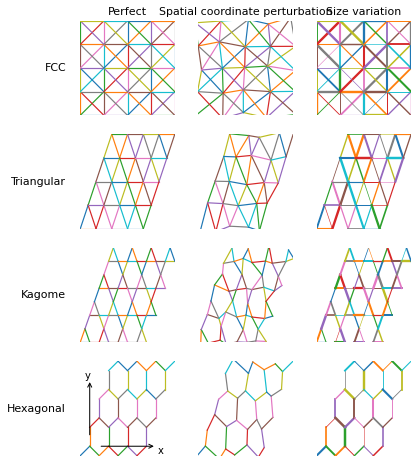

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helper to connect nearest neighbours ----------
def connect_nearest_neighbors(coords, factor=1.05):
    coords = np.asarray(coords)
    n = len(coords)
    d2 = np.zeros((n, n))
    min_d2 = np.inf

    for i in range(n):
        for j in range(i + 1, n):
            diff = coords[i] - coords[j]
            dist2 = diff[0] ** 2 + diff[1] ** 2
            d2[i, j] = d2[j, i] = dist2
            if dist2 > 1e-9 and dist2 < min_d2:
                min_d2 = dist2

    threshold2 = (factor ** 2) * min_d2
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            if d2[i, j] <= threshold2:
                edges.append((i, j))
    return edges

# ---------- Lattice generators ----------
def make_fcc(nx=4, ny=4):
    coords = []
    index = {}
    k = 0
    for j in range(ny + 1):
        for i in range(nx + 1):
            coords.append((i, j))
            index[(i, j)] = k
            k += 1
    coords = np.array(coords, dtype=float)

    edges = []
    for j in range(ny + 1):
        for i in range(nx + 1):
            if i < nx:
                edges.append((index[(i, j)], index[(i + 1, j)]))
            if j < ny:
                edges.append((index[(i, j)], index[(i, j + 1)]))
            if i < nx and j < ny:
                edges.append((index[(i, j)], index[(i + 1, j + 1)]))
                edges.append((index[(i + 1, j)], index[(i, j + 1)]))

    return coords, edges

def make_triangular(nx=4, ny=4, a=1.0):
    a1 = np.array([a, 0.0])
    a2 = np.array([0.5 * a, np.sqrt(3) / 2 * a])
    coords = []
    for n1 in range(nx + 1):
        for n2 in range(ny + 1):
            coords.append(n1 * a1 + n2 * a2)
    coords = np.array(coords)
    edges = connect_nearest_neighbors(coords)
    return coords, edges

def make_kagome(nx=4, ny=4, a=1.0):
    a1 = np.array([a, 0.0])
    a2 = np.array([0.5 * a, np.sqrt(3) / 2 * a])
    b1 = np.array([0.0, 0.0])
    b2 = 0.5 * a1
    b3 = 0.5 * a2
    coords = []
    for n1 in range(nx):
        for n2 in range(ny):
            R = n1 * a1 + n2 * a2
            coords.append(R + b1)
            coords.append(R + b2)
            coords.append(R + b3)
    coords = np.array(coords)
    edges = connect_nearest_neighbors(coords)
    return coords, edges

def make_hexagonal(nx=4, ny=4, a=1.0):
    # Honeycomb / hexagonal (graphene-style) lattice
    a1 = np.array([a, 0.0])
    a2 = np.array([0.5 * a, np.sqrt(3) / 2 * a])
    rA = (a1 + a2) / 3.0
    rB = 2.0 * (a1 + a2) / 3.0
    coords = []
    for n1 in range(nx):
        for n2 in range(ny):
            R = n1 * a1 + n2 * a2
            coords.append(R + rA)
            coords.append(R + rB)
    coords = np.array(coords)
    edges = connect_nearest_neighbors(coords)
    return coords, edges

# ---------- Drawing helper ----------
def normalize_coords(coords):
    coords = np.asarray(coords, dtype=float)
    min_x, min_y = coords.min(axis=0)
    max_x, max_y = coords.max(axis=0)
    span_x = max_x - min_x
    span_y = max_y - min_y
    # Prevent division by zero in degenerate cases
    if span_x == 0:
        span_x = 1.0
    if span_y == 0:
        span_y = 1.0
    coords_norm = coords.copy()
    coords_norm[:, 0] = (coords[:, 0] - min_x) / span_x
    coords_norm[:, 1] = (coords[:, 1] - min_y) / span_y
    return coords_norm

def draw_lattice(ax, coords, edges, variant="perfect", seed=0):
    rng = np.random.default_rng(seed)
    coords = normalize_coords(coords)
    if variant == "perturb":
        scale = 0.07
        coords = coords + scale * (rng.random(coords.shape) - 0.5)

    for idx, (i, j) in enumerate(edges):
        x = [coords[i, 0], coords[j, 0]]
        y = [coords[i, 1], coords[j, 1]]
        if variant == "size":
            lw = 0.5 + 2.0 * rng.random()
        else:
            lw = 1.2
        ax.plot(x, y, linewidth=lw)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_frame_on(False)

# ---------- Build the full 4x3 figure ----------
fig, axes = plt.subplots(4, 3, figsize=(6, 8))

row_names = ["FCC", "Triangular", "Kagome", "Hexagonal"]
col_names = ["Perfect", "Spatial coordinate perturbation", "Size variation"]

generators = [make_fcc, make_triangular, make_kagome, make_hexagonal]

for row, (name, gen) in enumerate(zip(row_names, generators)):
    coords, edges = gen()
    for col in range(3):
        ax = axes[row, col]
        if col == 0:
            variant = "perfect"
        elif col == 1:
            variant = "perturb"
        else:
            variant = "size"
        draw_lattice(ax, coords, edges, variant=variant, seed=10 + row * 3 + col)
    # Row labels on the left of the first column
    axes[row, 0].text(
        -0.15,
        0.5,
        name,
        ha="right",
        va="center",
        fontsize=11,
        transform=axes[row, 0].transAxes,
    )

# Column titles
for col, title in enumerate(col_names):
    axes[0, col].set_title(title, fontsize=11)

# Coordinate axes arrows in bottom-left panel
ax_ref = axes[-1, 0]
# y-arrow
ax_ref.annotate(
    "",
    xy=(0.1, 0.8),
    xytext=(0.1, 0.2),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    xycoords="axes fraction",
)
ax_ref.text(0.05, 0.82, "y", transform=ax_ref.transAxes, fontsize=10)
# x-arrow
ax_ref.annotate(
    "",
    xy=(0.8, 0.1),
    xytext=(0.2, 0.1),
    arrowprops=dict(arrowstyle="->", linewidth=1.0),
    xycoords="axes fraction",
)
ax_ref.text(0.82, 0.02, "x", transform=ax_ref.transAxes, fontsize=10)
